# 🧠 Computational Neurodynamics & ODE Jupyter Companion
### Target Audience: Physicians & Computational Neuroscience Researchers
### Focus: From LIF Electrophysiology to David Sussillo's RNN Population Dynamics & FORCE Algorithm

This Jupyter Notebook is a companion to your Neurodynamics Learning App. It allows you to simulate, analyze, and visualize neural dynamics using Python, NumPy, and Matplotlib. We will progress through three core computational milestones:
1. **Single-Neuron Electrophysiology**: The Leaky Integrate-and-Fire (LIF) Model.
2. **Coupled Network Oscillations**: The Basal Ganglia STN-GPe Loop in Parkinson's Disease & DBS Forcing.
3. **Recurrent Neural Networks (RNNs) as Continuous Dynamical Systems**: David Sussillo's population dynamics, attractor state-space, phase plane vector fields, and the **FORCE Algorithm** (Sussillo & Abbott, 2009).

---

## 1. Single-Neuron Electrophysiology: The LIF Model
The membrane potential $V(t)$ of a Leaky Integrate-and-Fire neuron is described by the linear first-order ordinary differential equation (ODE):

$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + R_m I_{ext}(t)$$

with a threshold condition: if $V(t) \ge V_{th}$, the neuron spikes ($V(t) \leftarrow V_{spike}$), and is immediately reset to a lower potential ($V(t) \leftarrow V_{reset}$) and enters a refractory period.

Let's write a numerical solver using **Euler's method** to integrate this ODE.

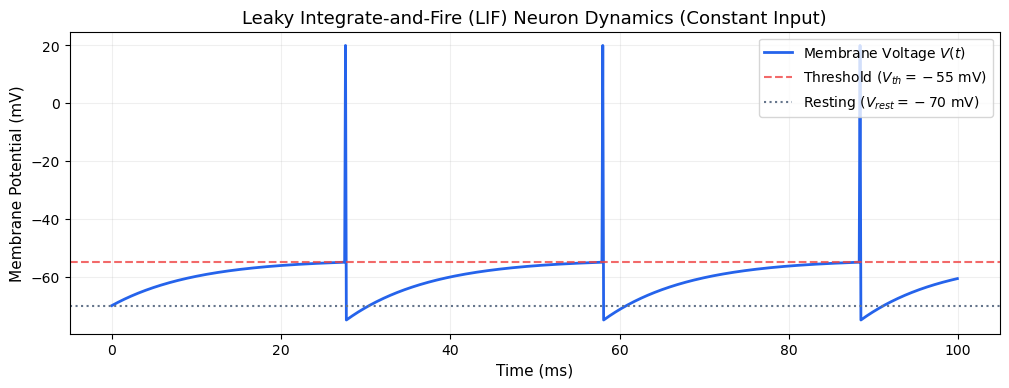

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define standard electrophysiological parameters
tau_m = 10.0      # Membrane time constant (ms)
V_rest = -70.0    # Resting potential (mV)
V_th = -55.0      # Action potential threshold (mV)
V_reset = -75.0   # Reset potential after spike (mV)
V_spike = 20.0    # Peak voltage during action potential (mV)
R_m = 1.0         # Membrane resistance (Gigaohms)

# Time settings
dt = 0.1          # Integration time-step (ms)
T = 100.0         # Total simulation time (ms)
t = np.arange(0, T, dt)

# Input current (constant stimulus)
I_ext = np.ones(len(t)) * 16.0  # 16 nA input current

# Arrays to store results
V = np.zeros(len(t))
V[0] = V_rest
spikes = []

# Euler Method Integration
for i in range(1, len(t)):
    # If the neuron spiked in the previous step, reset it
    if V[i-1] == V_spike:
        V[i] = V_reset
    else:
        # Calculate membrane rate of change (dV/dt)
        dVdt = (-(V[i-1] - V_rest) + R_m * I_ext[i-1]) / tau_m
        # Update voltage
        V[i] = V[i-1] + dVdt * dt
        
        # Check if threshold is crossed
        if V[i] >= V_th:
            V[i] = V_spike  # Action potential peak
            spikes.append(t[i])

# Plotting
plt.figure(figsize=(12, 4), dpi=100)
plt.plot(t, V, label='Membrane Voltage $V(t)$', color='#2563eb', lw=2)
plt.axhline(V_th, color='#ef4444', linestyle='--', label='Threshold ($V_{th} = -55$ mV)', alpha=0.8)
plt.axhline(V_rest, color='#64748b', linestyle=':', label='Resting ($V_{rest} = -70$ mV)')
plt.title('Leaky Integrate-and-Fire (LIF) Neuron Dynamics (Constant Input)', fontsize=13)
plt.xlabel('Time (ms)', fontsize=11)
plt.ylabel('Membrane Potential (mV)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

### 1.1 Sinusoidal/Oscillatory Input & Subthreshold Resonance
Real neural inputs are highly oscillatory. Let's see how our LIF model behaves when stimulated with a sinusoidal input current. We will study how the frequency of the input waves shapes the spiking pattern.

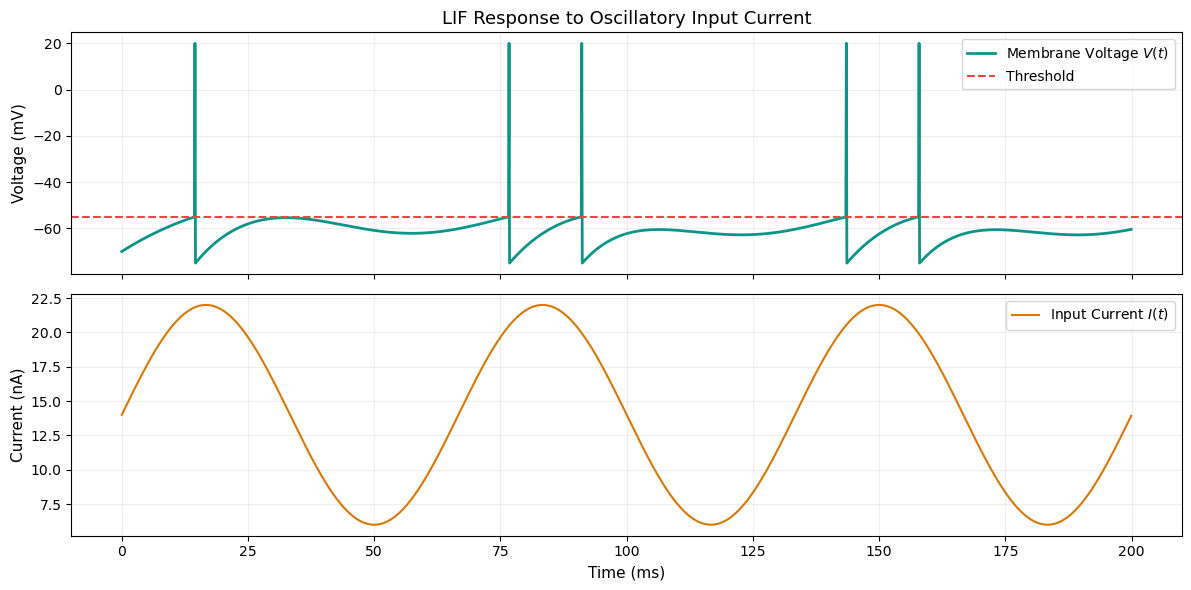

In [2]:
# Simulation parameters
T_osc = 200.0
t_osc = np.arange(0, T_osc, dt)

# Oscillation frequency (Hz = 1/s; so cycles per ms = frequency / 1000)
freq_hz = 15.0  # 15 Hz oscillations
freq_ms = freq_hz / 1000.0

# Current oscillates: I(t) = Baseline + Amplitude * sin(2 * pi * f * t)
I_baseline = 14.0
I_amplitude = 8.0
I_ext_osc = I_baseline + I_amplitude * np.sin(2 * np.pi * freq_ms * t_osc)

# Arrays to store results
V_osc = np.zeros(len(t_osc))
V_osc[0] = V_rest

# Euler Method Integration
for i in range(1, len(t_osc)):
    if V_osc[i-1] == V_spike:
        V_osc[i] = V_reset
    else:
        dVdt = (-(V_osc[i-1] - V_rest) + R_m * I_ext_osc[i-1]) / tau_m
        V_osc[i] = V_osc[i-1] + dVdt * dt
        if V_osc[i] >= V_th:
            V_osc[i] = V_spike

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, dpi=100)
ax1.plot(t_osc, V_osc, color='#0d9488', lw=2, label='Membrane Voltage $V(t)$')
ax1.axhline(V_th, color='#ef4444', linestyle='--', label='Threshold')
ax1.set_ylabel('Voltage (mV)', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)
ax1.set_title('LIF Response to Oscillatory Input Current', fontsize=13)

ax2.plot(t_osc, I_ext_osc, color='#d97706', lw=1.5, label='Input Current $I(t)$')
ax2.set_xlabel('Time (ms)', fontsize=11)
ax2.set_ylabel('Current (nA)', fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 2. Coupled Network Oscillations: The STN-GPe Loop in Parkinson's Disease
In the basal ganglia, the excitatory Subthalamic Nucleus (STN) and inhibitory Globus Pallidus externa (GPe) form a **coupled negative feedback loop**. In Parkinson's disease (dopamine depletion), this loop slips into pathological synchronous oscillations. Deep Brain Stimulation (DBS) injects high-frequency currents to disrupt these oscillations.

Let's model the STN and GPe as two coupled differential equations describing their population activity levels ($V_S$ and $V_G$):

$$\tau_S \frac{dV_S}{dt} = -(V_S - V_{S,rest}) - W_{GS} f(V_G) + I_{DBS}(t)$$
$$\tau_G \frac{dV_G}{dt} = -(V_G - V_{G,rest}) + W_{SG} f(V_S)$$

where $f(V) = \frac{1}{1 + e^{-k(V - V_{mid})}}$ is the non-linear sigmoid activation function.

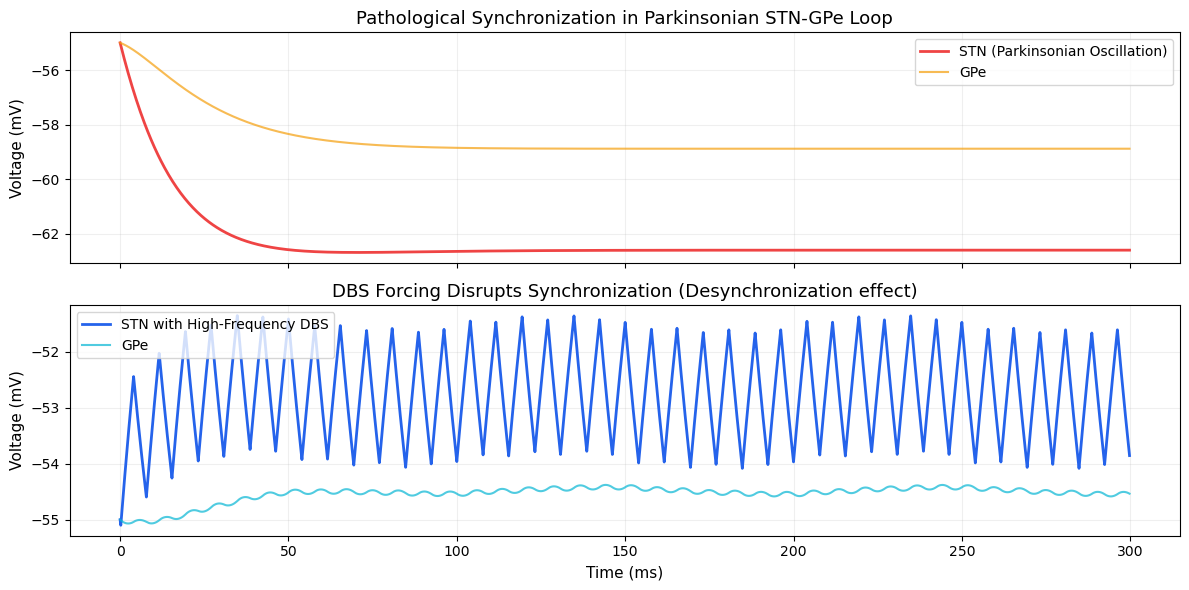

In [3]:
# STN-GPe parameters
tau_S = 20.0       # STN time constant (ms)
tau_G = 20.0       # GPe time constant (ms)
V_S_rest = -60.0   # STN resting potential (mV)
V_G_rest = -60.0   # GPe resting potential (mV)

# Coupling strengths
W_SG = 15.0        # Excitatory STN -> GPe connection
W_GS = 18.0        # Inhibitory GPe -> STN connection

# Sigmoid activation parameters
V_mid = -50.0      # Midpoint activation (mV)
k = 0.2            # Slope parameter

def f(V):
    return 1.0 / (1.0 + np.exp(-k * (V - V_mid)))

# Simulation settings
dt_net = 0.2
T_net = 300.0
t_net = np.arange(0, T_net, dt_net)

# DBS stimulation settings (High frequency forcing: 130 Hz)
dbs_freq_hz = 130.0
dbs_freq_ms = dbs_freq_hz / 1000.0
dbs_amplitude = 25.0

# We simulate two conditions: Parkinsonian (pathological oscillation) vs. DBS Active
def simulate_network(with_dbs=False):
    V_S = np.zeros(len(t_net))
    V_G = np.zeros(len(t_net))
    V_S[0] = -55.0  # Slightly perturbed starting condition
    V_G[0] = -55.0
    
    for i in range(1, len(t_net)):
        # DBS forcing function
        I_dbs = dbs_amplitude * (np.sin(2 * np.pi * dbs_freq_ms * t_net[i-1]) > 0.0) if with_dbs else 0.0
        
        # STN derivative
        dVS_dt = (-(V_S[i-1] - V_S_rest) - W_GS * f(V_G[i-1]) + I_dbs) / tau_S
        # GPe derivative
        dVG_dt = (-(V_G[i-1] - V_G_rest) + W_SG * f(V_S[i-1])) / tau_G
        
        # Euler step
        V_S[i] = V_S[i-1] + dVS_dt * dt_net
        V_G[i] = V_G[i-1] + dVG_dt * dt_net
        
    return V_S, V_G

# Run simulations
VS_parkinson, VG_parkinson = simulate_network(with_dbs=False)
VS_dbs, VG_dbs = simulate_network(with_dbs=True)

# Plotting comparisons
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, dpi=100)

ax1.plot(t_net, VS_parkinson, color='#ef4444', lw=2, label='STN (Parkinsonian Oscillation)')
ax1.plot(t_net, VG_parkinson, color='#f59e0b', lw=1.5, label='GPe', alpha=0.7)
ax1.set_ylabel('Voltage (mV)', fontsize=11)
ax1.set_title('Pathological Synchronization in Parkinsonian STN-GPe Loop', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(t_net, VS_dbs, color='#2563eb', lw=2, label='STN with High-Frequency DBS')
ax2.plot(t_net, VG_dbs, color='#06b6d4', lw=1.5, label='GPe', alpha=0.7)
ax2.set_xlabel('Time (ms)', fontsize=11)
ax2.set_ylabel('Voltage (mV)', fontsize=11)
ax2.set_title('DBS Forcing Disrupts Synchronization (Desynchronization effect)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 3. Recurrent Neural Networks (RNNs) as Continuous Dynamical Systems
Modern computational neuroscience shifts focus from single neurons to **population-level dynamics**. Following David Sussillo's pioneering work (*Computation through Neural Population Dynamics*, Nature Neuroscience 2013), a recurrent neural network with $N$ units can be modeled as a continuous-time dynamical system governed by a system of coupled first-order ODEs:

$$\tau \frac{dx_i}{dt} = -x_i + \sum_{j=1}^{N} W_{ij} \tanh(x_j) + I_i(t)$$

where:
- $x_i(t)$ is the activation state (e.g., membrane current) of unit $i$.
- $h_i(t) = \tanh(x_i(t))$ is the firing rate of unit $i$ (bounded between -1 and 1).
- $W$ is the connectivity weight matrix ($N \times N$).
- $\tau$ is the time constant.
- $I_i(t)$ is the external input.

To understand how this network performs computations, we analyze its **state space topology**, find **fixed points** (where $dx/dt = 0$), and visualize the **attractor landscape**.

### 3.1 Phase Portrait and Vector Field of a 2-Unit RNN
Let's write a Python script to visualize the vector field, nullclines, and fixed points of a 2-unit recurrent network. The system is:

$$\tau \frac{dx_1}{dt} = -x_1 + W_{11} \tanh(x_1) + W_{21} \tanh(x_2)$$
$$\tau \frac{dx_2}{dt} = -x_2 + W_{12} \tanh(x_1) + W_{22} \tanh(x_2)$$

C:\Users\User\AppData\Local\Temp\ipykernel_35844\3634095562.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, -X1 + W_rnn[0,0]*np.tanh(X1) + W_rnn[0,1]*np.tanh(X2), [0], colors='magenta', linestyles='--', linewidths=2, label='$dx_1/dt=0$ Nullcline')
C:\Users\User\AppData\Local\Temp\ipykernel_35844\3634095562.py:38: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, -X2 + W_rnn[1,0]*np.tanh(X1) + W_rnn[1,1]*np.tanh(X2), [0], colors='cyan', linestyles='--', linewidths=2, label='$dx_2/dt=0$ Nullcline')


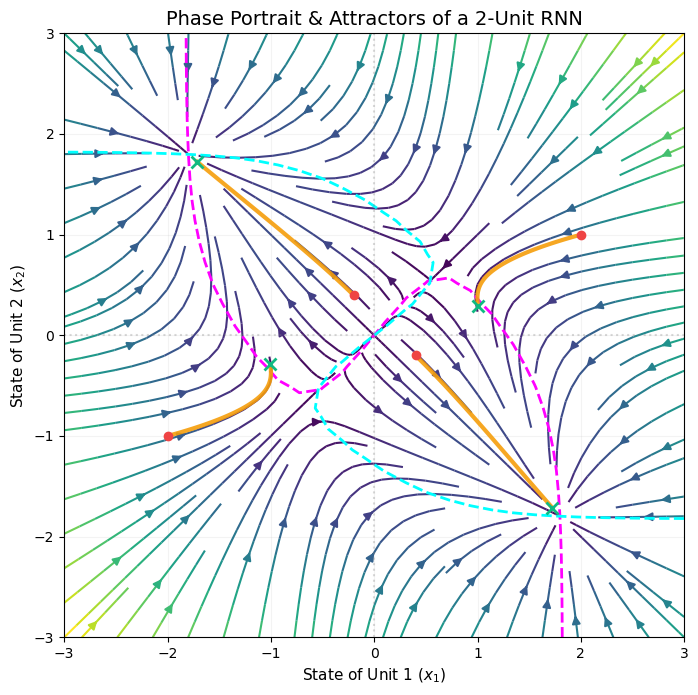

In [4]:
# Connectivity weights for our 2-unit network
# We configure it to have two stable fixed points (bistable system, functioning as a 1-bit memory)
W_rnn = np.array([
    [1.5, -0.4],
    [-0.4, 1.5]
])
tau_rnn = 10.0

def rnn_deriv(x, t=0):
    # x is a vector of shape (2,)
    rates = np.tanh(x)
    dxdt = (-x + np.dot(W_rnn, rates)) / tau_rnn
    return dxdt

# Create grid in state space
x1_range = np.linspace(-3, 3, 30)
x2_range = np.linspace(-3, 3, 30)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Calculate vector field
U = np.zeros(X1.shape)
V_dir = np.zeros(X2.shape)
for idx in range(X1.shape[0]):
    for jdx in range(X1.shape[1]):
        x_vec = np.array([X1[idx, jdx], X2[idx, jdx]])
        dxdt = rnn_deriv(x_vec)
        U[idx, jdx] = dxdt[0]
        V_dir[idx, jdx] = dxdt[1]

# Plot Phase Portrait
plt.figure(figsize=(8, 8), dpi=100)
plt.streamplot(X1, X2, U, V_dir, color=np.sqrt(U**2 + V_dir**2), cmap='viridis', density=1.2, arrowsize=1.2)

# Plot Nullclines (where dx1/dt = 0 and dx2/dt = 0)
# dx1/dt = 0 => x1 = W_11 tanh(x1) + W_21 tanh(x2)
# dx2/dt = 0 => x2 = W_12 tanh(x1) + W_22 tanh(x2)
plt.contour(X1, X2, -X1 + W_rnn[0,0]*np.tanh(X1) + W_rnn[0,1]*np.tanh(X2), [0], colors='magenta', linestyles='--', linewidths=2, label='$dx_1/dt=0$ Nullcline')
plt.contour(X1, X2, -X2 + W_rnn[1,0]*np.tanh(X1) + W_rnn[1,1]*np.tanh(X2), [0], colors='cyan', linestyles='--', linewidths=2, label='$dx_2/dt=0$ Nullcline')

# Simulate trajectories starting from different initial conditions
init_conditions = [
    np.array([-2.0, -1.0]),
    np.array([2.0, 1.0]),
    np.array([-0.2, 0.4]),
    np.array([0.4, -0.2])
]

dt_rnn = 0.5
t_rnn_steps = 100
for x_init in init_conditions:
    traj = np.zeros((t_rnn_steps, 2))
    traj[0] = x_init
    for step in range(1, t_rnn_steps):
        deriv = rnn_deriv(traj[step-1])
        traj[step] = traj[step-1] + deriv * dt_rnn
    plt.plot(traj[:, 0], traj[:, 1], color='#f59e0b', lw=3, alpha=0.9)
    plt.plot(traj[0, 0], traj[0, 1], 'o', color='#ef4444', markersize=6)
    plt.plot(traj[-1, 0], traj[-1, 1], 'x', color='#10b981', markersize=8, mew=2)

plt.axhline(0, color='gray', alpha=0.3, ls=':')
plt.axvline(0, color='gray', alpha=0.3, ls=':')
plt.title('Phase Portrait & Attractors of a 2-Unit RNN', fontsize=14)
plt.xlabel('State of Unit 1 ($x_1$)', fontsize=11)
plt.ylabel('State of Unit 2 ($x_2$)', fontsize=11)
plt.grid(True, alpha=0.15)
plt.show()

### 3.2 Interpretation of the Phase Portrait
Looking at the plot above:
1. **Attractors (Green X)**: There are two stable fixed points (in the top-right and bottom-left quadrants). Trajectories starting in these basins of attraction converge here. This acts as a **bistable memory motif**.
2. **Saddle Point (Origin 0,0)**: The origin is an unstable fixed point. If a trajectory starts exactly on the diagonal dividing line (separatrix), it will flow towards the origin and then slide off to one of the stable attractors. This is a **decision-making saddle motif**.
3. **Nullclines (Magenta and Cyan)**: The intersections of the nullclines are the exact positions of the fixed points! You can clearly see three intersection points (two stable, one unstable).

### 3.3 The FORCE Algorithm (Sussillo & Abbott, 2009)
The FORCE algorithm (First-Order Reduced Controller for RNNs) trains a chaotic, high-dimensional Recurrent Neural Network to generate complex, high-frequency, non-linear trajectories by feeding back the output to the network and modifying the output weights $W^{out}$ online using **Recursive Least Squares (RLS)**.

Let's write a simplified simulation of the **FORCE Algorithm** stabilizing chaotic neural activity to generate a target sine-wave pattern.

Training RNN using FORCE algorithm...
FORCE Training completed!


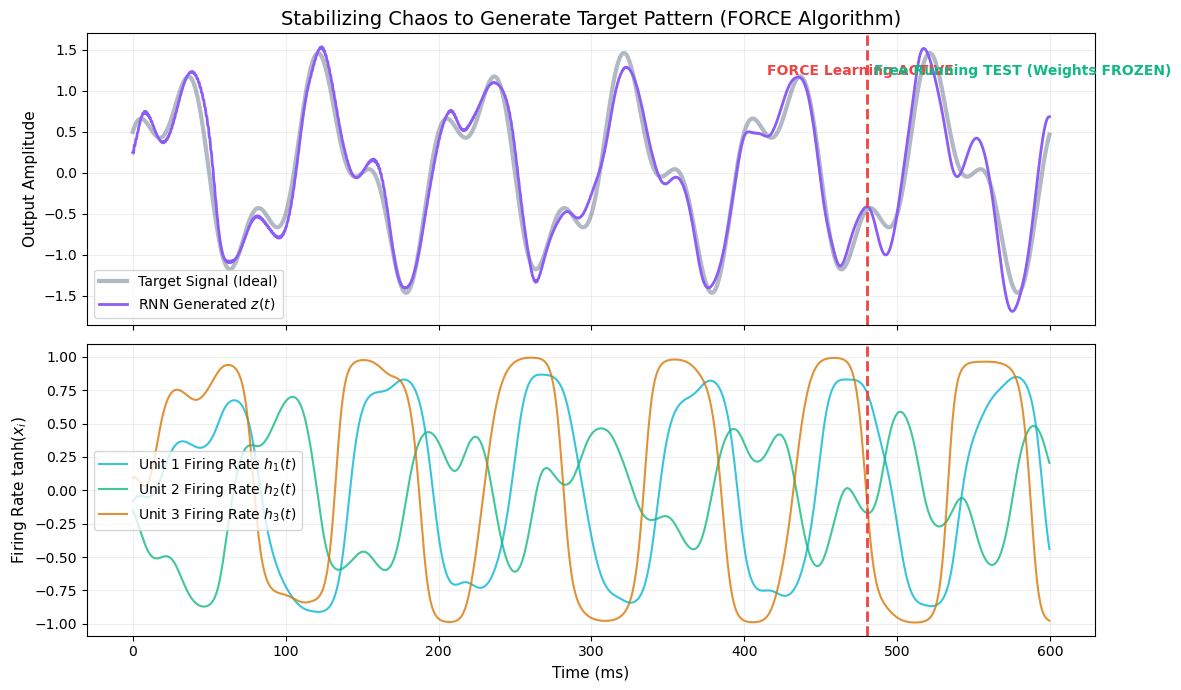

In [5]:
# Let's set up a network of N = 100 units
N = 100
g = 1.5           # Chaos scale (g > 1.0 means highly chaotic free-running dynamics)
alpha = 1.0       # RLS initialization scale
dt_f = 0.5
T_f = 600.0
t_f = np.arange(0, T_f, dt_f)

np.random.seed(42)

# Sparse random connectivity matrix with normal distribution
W_M = np.random.normal(0.0, g / np.sqrt(N), size=(N, N))
# Output feedback matrix (feedback of generated signal into network)
W_fb = np.random.uniform(-1.0, 1.0, size=(N, 1))
# Readout weights initialized to zero
W_out = np.zeros((N, 1))

# Recursive Least Squares correlation matrix inverse
P = np.eye(N) * alpha

# Target function: A complex signal we want to learn (e.g. combination of two frequencies)
target = 1.0 * np.sin(2 * np.pi * 0.01 * t_f) + 0.5 * np.cos(2 * np.pi * 0.025 * t_f)

# Run variables
x = np.random.normal(0.0, 0.1, size=(N, 1))
r = np.tanh(x)
z = np.dot(W_out.T, r)[0, 0] # Output read-out

# Output stores
outputs = np.zeros(len(t_f))
network_states = np.zeros((len(t_f), 3)) # Track 3 units

print("Training RNN using FORCE algorithm...")
for i in range(len(t_f)):
    # ODE Euler Step
    # Internal states update driven by recurrent connections and feedback of current output
    dx_dt = (-x + np.dot(W_M, r) + np.dot(W_fb, z)) / 10.0
    x = x + dx_dt * dt_f
    r = np.tanh(x)
    
    # RLS Update (FORCE training phase - active for the first 80% of simulation)
    if i < int(0.8 * len(t_f)) and i % 2 == 0:
        # Calculate projected matrix multiplication
        k_vec = np.dot(P, r)
        c_val = 1.0 / (1.0 + np.dot(r.T, k_vec)[0, 0])
        P = P - c_val * np.dot(k_vec, k_vec.T)
        
        # Read out error
        z = np.dot(W_out.T, r)[0, 0]
        error = target[i] - z
        
        # Update readout weights
        W_out = W_out + error * c_val * k_vec
        
    # Calculate readout with new weights
    z = np.dot(W_out.T, r)[0, 0]
    outputs[i] = z
    network_states[i, :] = r[:3, 0]

print("FORCE Training completed!")

# Plot FORCE results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, dpi=100)

# Training vs Test border
border_t = t_f[int(0.8 * len(t_f))]

ax1.plot(t_f, target, color='#64748b', lw=3, label='Target Signal (Ideal)', alpha=0.5)
ax1.plot(t_f, outputs, color='#8b5cf6', lw=2, label='RNN Generated $z(t)$')
ax1.axvline(border_t, color='#ef4444', ls='--', lw=2)
ax1.text(border_t - 65, 1.2, 'FORCE Learning ACTIVE', color='#ef4444', fontweight='bold')
ax1.text(border_t + 5, 1.2, 'Free Running TEST (Weights FROZEN)', color='#10b981', fontweight='bold')
ax1.set_ylabel('Output Amplitude', fontsize=11)
ax1.set_title('Stabilizing Chaos to Generate Target Pattern (FORCE Algorithm)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(t_f, network_states[:, 0], color='#06b6d4', label='Unit 1 Firing Rate $h_1(t)$', alpha=0.8)
ax2.plot(t_f, network_states[:, 1], color='#10b981', label='Unit 2 Firing Rate $h_2(t)$', alpha=0.8)
ax2.plot(t_f, network_states[:, 2], color='#d97706', label='Unit 3 Firing Rate $h_3(t)$', alpha=0.8)
ax2.axvline(border_t, color='#ef4444', ls='--', lw=2)
ax2.set_xlabel('Time (ms)', fontsize=11)
ax2.set_ylabel('Firing Rate $\\tanh(x_i)$', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### 3.4 Summary of David Sussillo's RNN Population Dynamics
From this experiment, we observe a vital lesson about continuous recurrent neural networks:
1. **Stabilizing Chaos**: Free-running random networks with strong connections ($g > 1.0$) are chaotic and behave unpredictably. However, the **FORCE algorithm** can stabilize this chaos dynamically, matching complex target signals by modifying *only* the readout weights and feeding back the error.
2. **State Space Representation**: Rather than a single neuron controlling a single action, the collective state space of $N$ units forms a low-dimensional trajectory (like an orbit or limit cycle) that carries the coding representation. This is the cornerstone of **Computation through Neural Population Dynamics**.